# Import the required libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the datasets

In [6]:
purchase_df = pd.read_csv('/content/QVI_purchase_behaviour.csv')
transactions_df = pd.read_excel('/content/QVI_transaction_data.xlsx')

# Inspect the datasets

Inspect the purchase behaviour dataset

In [7]:
purchase_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [8]:
purchase_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [9]:
purchase_df.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [10]:
purchase_df.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


The purchase behaviour dataset doesnt contain any null values

In [11]:
purchase_df.dtypes

,0
LYLTY_CARD_NBR,int64
LIFESTAGE,object
PREMIUM_CUSTOMER,object


The purchase behaviour dataset has correct datatypes

In [12]:
purchase_df.duplicated().sum()

np.int64(0)

The purchase dataset has no duplicated values

Inspect the transaction data dataset

In [13]:
transactions_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [14]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [15]:
transactions_df.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


The transactions dataset doesnt have any missing values

In [16]:
transactions_df.dtypes

,0
DATE,int64
STORE_NBR,int64
LYLTY_CARD_NBR,int64
TXN_ID,int64
PROD_NBR,int64
PROD_NAME,object
PROD_QTY,int64
TOT_SALES,float64


The data types are correct in the transactions dataset

In [17]:
transactions_df.duplicated().sum()

np.int64(1)

The transaction has 1 duplicated value

Drop the duplicate value

In [18]:
transactions_df.drop_duplicates(inplace=True)

## Merge the datasets

In [19]:
merged_df = pd.merge(transactions_df, purchase_df, on='LYLTY_CARD_NBR', how='inner')
merged_df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget


# EDA

## Feature Engineering: Extracting Pack Size and Brand

### Extracting `PACK_SIZE` and `Brand`

In [32]:
merged_df['PACK_SIZE'] = merged_df['PROD_NAME'].str.extract(r'(\d+)(?:g|ml)').astype(pd.Int64Dtype())
display(merged_df.head())

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,BRAND,PACK_SIZE
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,NATURAL,175
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget,CCS,175
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,SMITHS,170
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,SMITHS,175
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,KETTLE,150


## Analyse Customer Segments

###Total Sales

In [24]:
# which segment drives the most sales?
sales_by_segment = merged_df.groupby(['PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
display(sales_by_segment.head())

,PREMIUM_CUSTOMER,TOT_SALES
0,Budget,676211.55
1,Mainstream,750744.50
2,Premium,507452.95


Text(0.5, 0, 'Customer Segment')

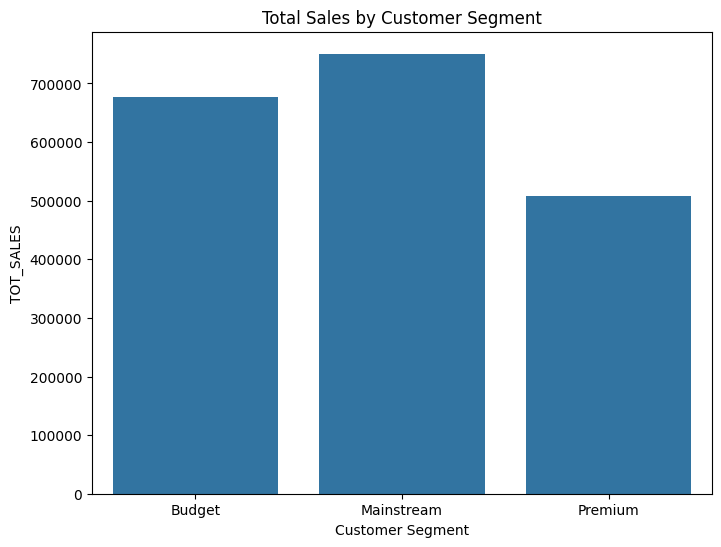

In [25]:
plt.figure(figsize=(8, 6))
sns.barplot(x='PREMIUM_CUSTOMER', y='TOT_SALES', data=sales_by_segment)
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')

Mainstream customers drive the most sales

Customers at which lifestage drives the most sales?

In [26]:
sales_by_lifestage = merged_df.groupby(['LIFESTAGE'])['TOT_SALES'].sum().reset_index()
sales_by_lifestage.head()

,LIFESTAGE,TOT_SALES
0,MIDAGE SINGLES/COUPLES,184751.30
1,NEW FAMILIES,50433.45
2,OLDER FAMILIES,353767.20
3,OLDER SINGLES/COUPLES,402420.75
4,RETIREES,366470.90


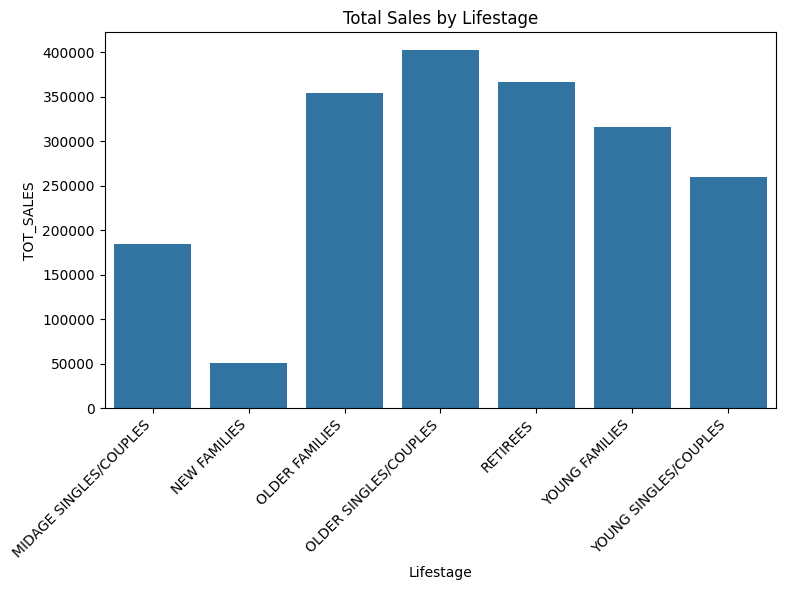

In [29]:
plt.figure(figsize=(8,6))
sns.barplot(x='LIFESTAGE', y='TOT_SALES', data=sales_by_lifestage)
plt.title('Total Sales by Lifestage')
plt.xlabel('Lifestage')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Older singles/Couples drive the most sales in the lifestage segment

###  Total Sales by Lifestage and Premium Customer segments

In [57]:
sales_by_both_segments = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()

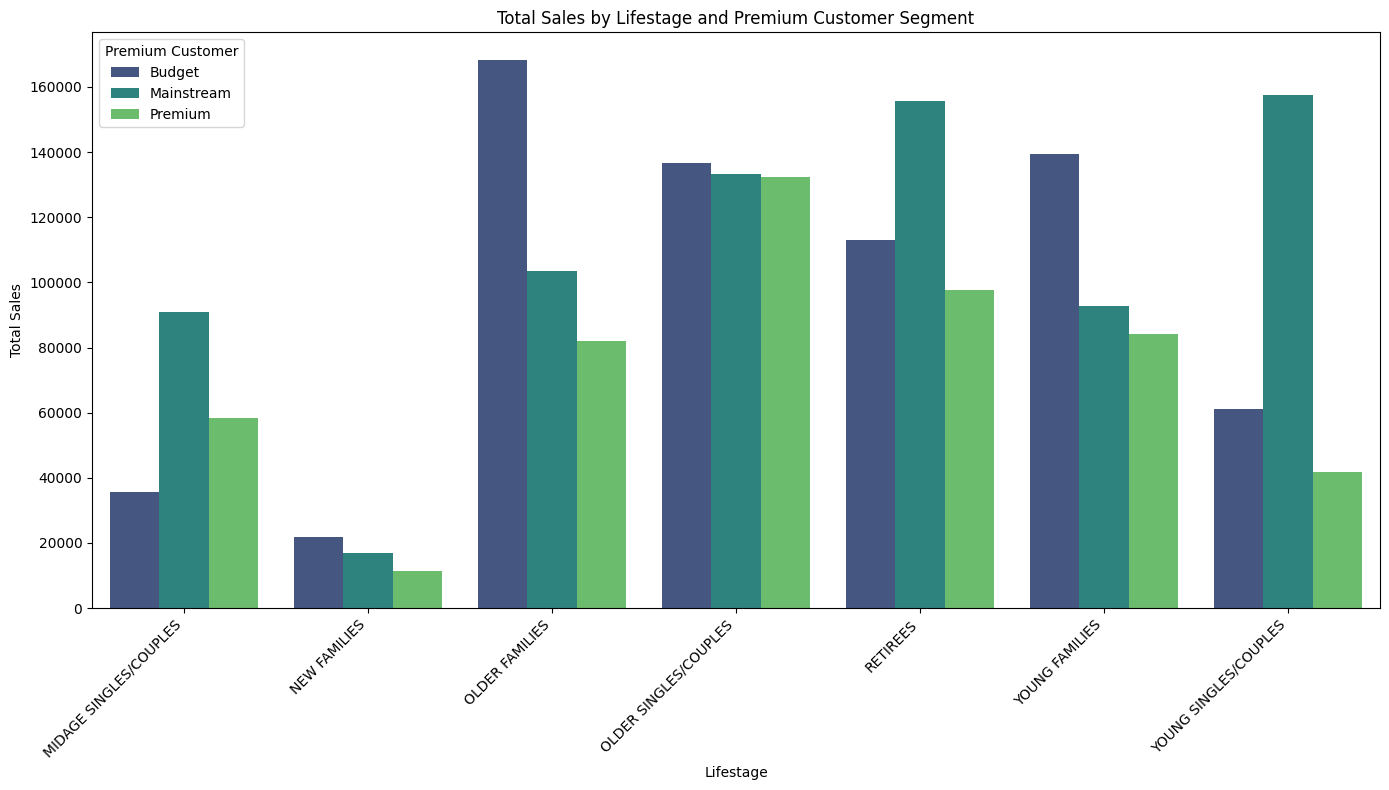

In [56]:
plt.figure(figsize=(14, 8))
sns.barplot(x='LIFESTAGE', y='TOT_SALES', hue='PREMIUM_CUSTOMER', data=sales_by_both_segments, palette='viridis')
plt.title('Total Sales by Lifestage and Premium Customer Segment')
plt.xlabel('Lifestage')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer')
plt.tight_layout()
plt.show()

### Customers

which segment has the most customers?

In [38]:
segment_customers = merged_df.groupby(['PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
segment_customers.head()

,PREMIUM_CUSTOMER,LYLTY_CARD_NBR
0,Budget,24470
1,Mainstream,29245
2,Premium,18922


Text(0.5, 0, 'Customer Segment')

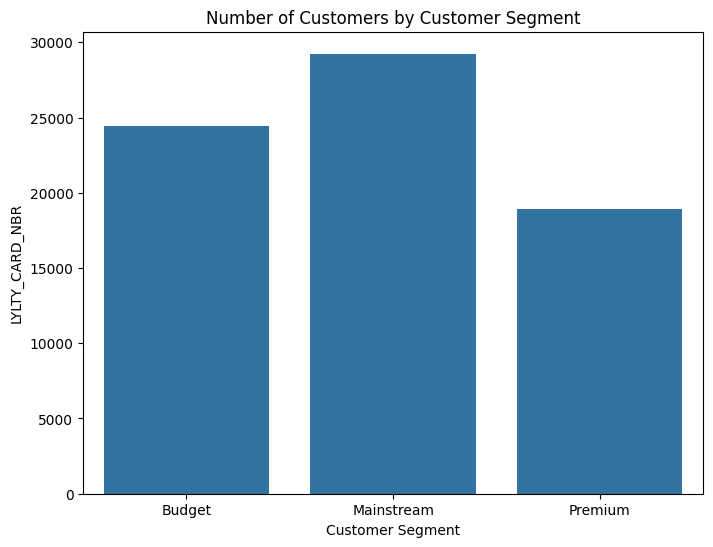

In [39]:
plt.figure(figsize=(8,6))
sns.barplot(x='PREMIUM_CUSTOMER', y='LYLTY_CARD_NBR', data=segment_customers)
plt.title('Number of Customers by Customer Segment')
plt.xlabel('Customer Segment')

The mainstream customer segment has the most customers

Which lifestage has the most customers?

In [61]:
customer_by_lifestage = merged_df.groupby(['LIFESTAGE'])['LYLTY_CARD_NBR'].nunique().reset_index()
customer_by_lifestage

,LIFESTAGE,LYLTY_CARD_NBR
0,MIDAGE SINGLES/COUPLES,7275
1,NEW FAMILIES,2549
2,OLDER FAMILIES,9780
3,OLDER SINGLES/COUPLES,14609
4,RETIREES,14805
5,YOUNG FAMILIES,9178
6,YOUNG SINGLES/COUPLES,14441


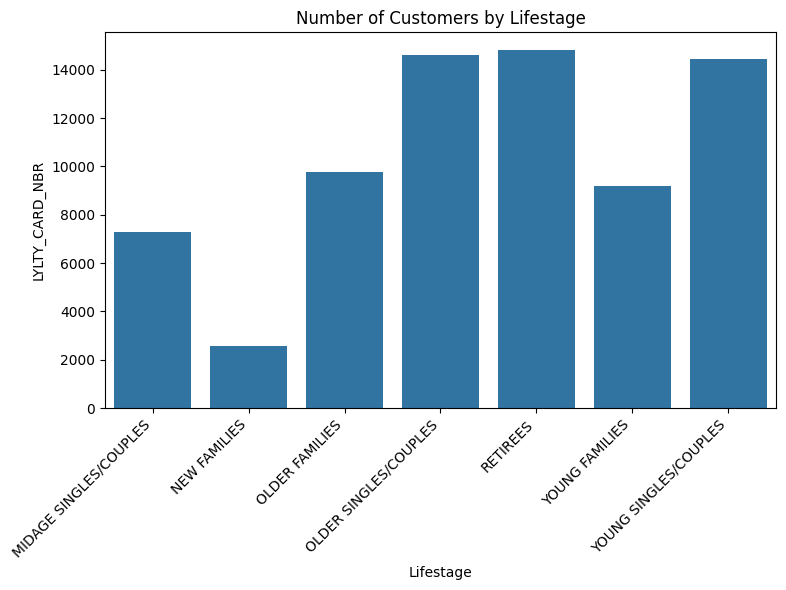

In [48]:
plt.figure(figsize=(8,6))
sns.barplot(x='LIFESTAGE', y='LYLTY_CARD_NBR', data=customer_by_lifestage)
plt.title('Number of Customers by Lifestage')
plt.xlabel('Lifestage')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [60]:
customers_by_both_segments = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().reset_index()
customers_by_both_segments.rename(columns={'LYLTY_CARD_NBR': 'NUMBER_OF_CUSTOMERS'}, inplace=True)

### Visualize Number of Customers by Lifestage and Premium Customer

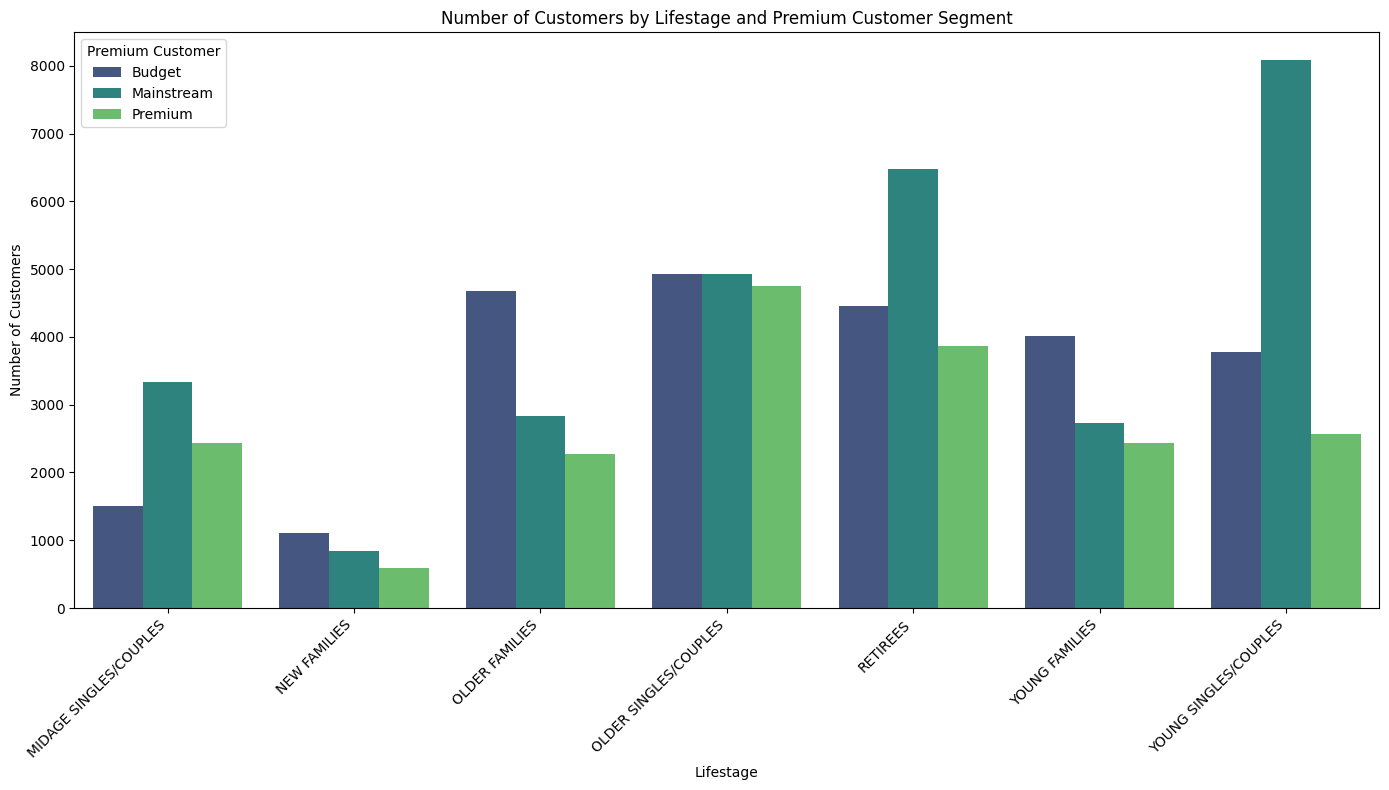

In [59]:
plt.figure(figsize=(14, 8))
sns.barplot(x='LIFESTAGE', y='NUMBER_OF_CUSTOMERS', hue='PREMIUM_CUSTOMER', data=customers_by_both_segments, palette='viridis')
plt.title('Number of Customers by Lifestage and Premium Customer Segment')
plt.xlabel('Lifestage')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer')
plt.tight_layout()
plt.show()

##Analyze brands

In [49]:
df_brand = merged_df.groupby(['BRAND'])['TOT_SALES'].sum().reset_index()
df_brand.head()

,BRAND,TOT_SALES
0,BURGER,6831.0
1,CCS,18078.9
2,CHEETOS,16884.5
3,CHEEZELS,40029.9
4,COBS,70569.8


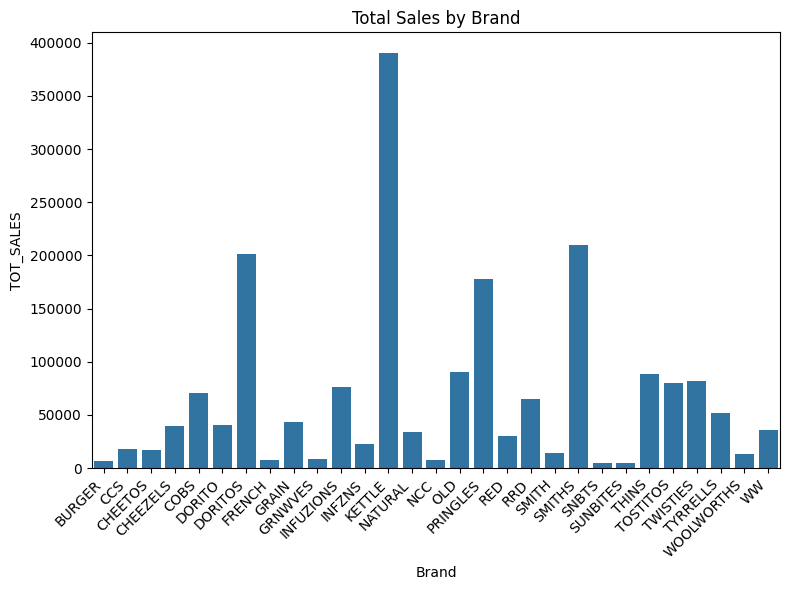

In [51]:
plt.figure(figsize=(8,6))
sns.barplot(x='BRAND', y='TOT_SALES', data=df_brand)
plt.title('Total Sales by Brand')
plt.xlabel('Brand')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## Analyze by pack sizes

In [52]:
df_pack_size = merged_df.groupby(['PACK_SIZE'])['TOT_SALES'].sum().reset_index()
df_pack_size.head()

,PACK_SIZE,TOT_SALES
0,70,6852.0
1,90,9676.4
2,110,162765.4
3,125,5733.0
4,134,177655.5


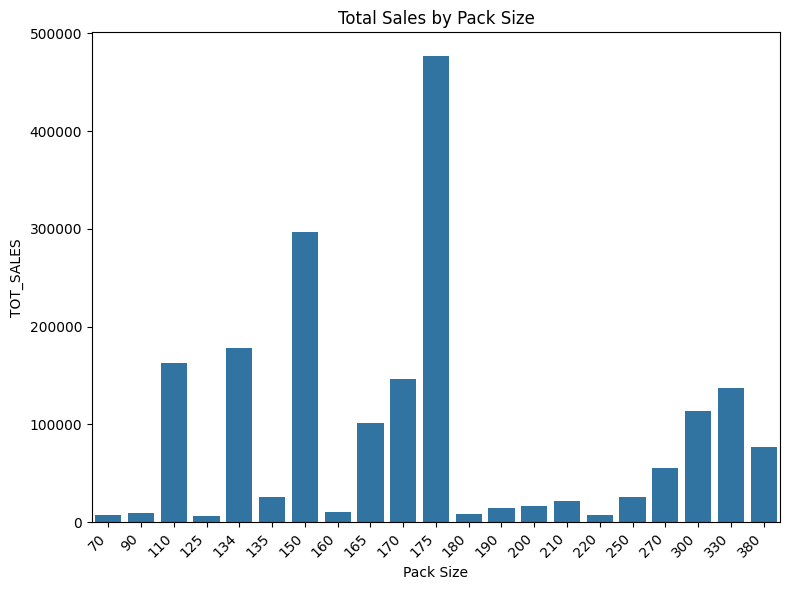

In [54]:
plt.figure(figsize=(8,6))
sns.barplot(x='PACK_SIZE', y='TOT_SALES', data=df_pack_size)
plt.title('Total Sales by Pack Size')
plt.xlabel('Pack Size')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

packet sizes influence sales , the 175g is the most popular pack size

# Findings





The mainstream customer segment drives the most sales and also has the most customers.

The older singles/couples segment signalling age drives the most sales

The retirees have the highest number of customers in that segment

Kettle brand drives the most sales

175g is the most purchased size

# Recommendations

Focus on retaining the mainstream customer segment across all life stages.
You could implement loyalty programs, give personalized promotions based on purchasing history.
Also explore opportunities for cross selling with their purchasing patterns

Target older families as they also drive the most sales. Take into account that they are value concious and prefer budgted items.You can offer family-sized packs, multi-buy deals and understand their preferences to tailor offers for them

Stock up more kettle products as it seems like a preffered brand. Also stock up 175g packets more as it is also a preffered size to drive more sales.

New families drive the least sales,they show a preference to budgeted items. Look into why the sales are so low and how you can improve sales.

Athough the volume of premium customers is low , they purchase more premium products which lead to higher profit margins. Offer premium branded products or new flavours or limited editions to cater to this specific demographic.